In [1]:
# Import necessary libraries
import torch
import cv2
import numpy as np
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from PIL import Image
import plotly.graph_objects as go
from transformers import pipeline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [4]:

# Define folder path and load images
folder = "../static/uploads/test-ring"
front_path = f"{folder}/front.png"
back_path = f"{folder}/back.png"
top_path = f"{folder}/top.png"


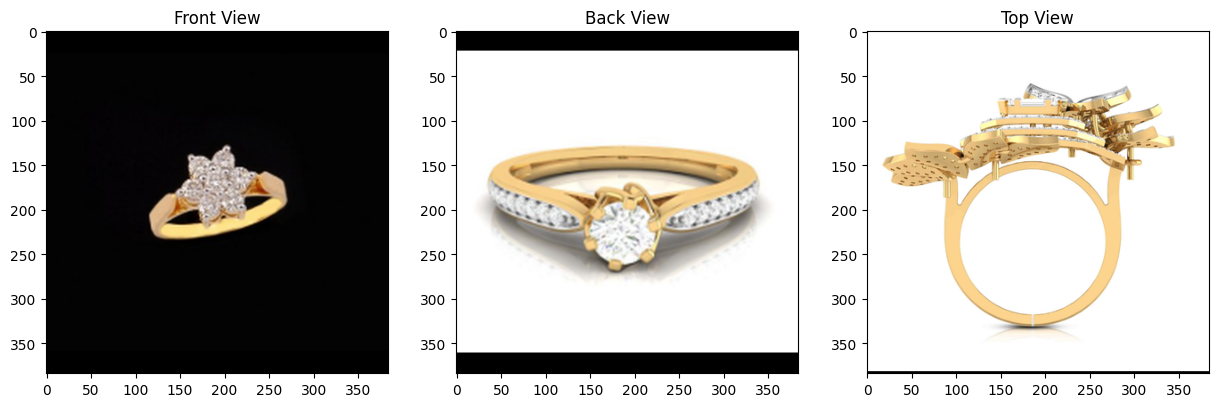

In [7]:

def load_and_resize_image(path, target_size=(384, 384)):
    """Load image and resize while maintaining aspect ratio"""
    # Open image with PIL
    img = Image.open(path)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    
    # Convert to RGB mode
    img = img.convert('RGB')
    
    # Calculate aspect ratio preserving resize dimensions
    w, h = img.size
    aspect = w / h
    
    if aspect > 1:
        new_w = target_size[0]
        new_h = int(target_size[0] / aspect)
    else:
        new_h = target_size[1]
        new_w = int(target_size[1] * aspect)
    
    # Create new image with padding
    resized_img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    new_img = Image.new('RGB', target_size, (0, 0, 0))
    
    # Paste resized image in center
    paste_x = (target_size[0] - new_w) // 2
    paste_y = (target_size[1] - new_h) // 2
    new_img.paste(resized_img, (paste_x, paste_y))
    
    return new_img

# Load and resize images
front_img = load_and_resize_image(front_path)
back_img = load_and_resize_image(back_path)
top_img = load_and_resize_image(top_path)

# Plot original images
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(front_img)
plt.title('Front View')
plt.subplot(132)
plt.imshow(back_img)
plt.title('Back View')
plt.subplot(133)
plt.imshow(top_img)
plt.title('Top View')
plt.show()


Initializing depth estimation model...
Using device: cuda
Generating depth maps...
Processing depth map for image of size (384, 384)...
Generated depth map of shape (384, 384)
Processing depth map for image of size (384, 384)...
Generated depth map of shape (384, 384)
Processing depth map for image of size (384, 384)...
Generated depth map of shape (384, 384)


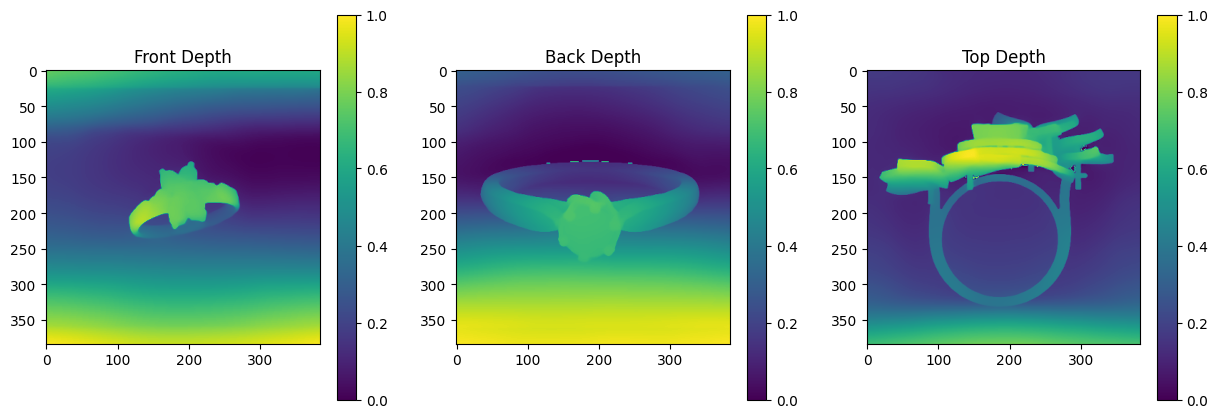

In [8]:
# Initialize depth estimation model
print("Initializing depth estimation model...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
depth_model = pipeline("depth-estimation", model="depth-anything/Depth-Anything-V2-base-hf", device=device)

def get_depth_map(img):
    """Estimate depth map from PIL image"""
    print(f"Processing depth map for image of size {img.size}...")
    predictions = depth_model(img)
    depth_map = np.array(predictions["depth"])
    # Normalize depth map to [0, 1]
    depth_map = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())
    print(f"Generated depth map of shape {depth_map.shape}")
    return depth_map

# Get depth maps for each view
print("Generating depth maps...")
front_depth = get_depth_map(front_img)
back_depth = get_depth_map(back_img)
top_depth = get_depth_map(top_img)

# Plot depth maps
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(front_depth, cmap='viridis')
plt.title('Front Depth')
plt.colorbar()
plt.subplot(132)
plt.imshow(back_depth, cmap='viridis')
plt.title('Back Depth')
plt.colorbar()
plt.subplot(133)
plt.imshow(top_depth, cmap='viridis')
plt.title('Top Depth')
plt.colorbar()
plt.show()

In [19]:
def generate_point_cloud(depth_map, view_type='front', threshold=0.1):
    """
    Generate point cloud from depth map based on view type.
    
    In 3D reconstruction, we need to convert 2D depth maps into 3D points.
    For each pixel in the depth map:
    - front/back views: (x, y) become X,Y coords, depth becomes Z
    - top view: (x, y) become X,Z coords, depth becomes Y
    """
    print(f"\nGenerating point cloud for {view_type} view...")
    print(f"Input depth map shape: {depth_map.shape}")
    
    h, w = depth_map.shape
    
    # Create coordinate grids
    # np.meshgrid creates 2D coordinate arrays for all combinations of x and y
    x_coords, y_coords = np.meshgrid(np.linspace(-1, 1, w), np.linspace(-1, 1, h))
    
    # Filter out low confidence points
    mask = depth_map > threshold
    print(f"Points above threshold: {np.sum(mask)}")
    
    # Prepare coordinates based on view type
    if view_type == 'front':
        # For front view: x_coords→X, y_coords→Y, depth→Z
        points = np.column_stack([
            x_coords[mask].flatten(),
            y_coords[mask].flatten(),
            depth_map[mask].flatten()
        ])
    elif view_type == 'back':
        # For back view: x_coords→X, y_coords→Y, -depth→Z
        points = np.column_stack([
            x_coords[mask].flatten(),
            y_coords[mask].flatten(),
            -depth_map[mask].flatten()
        ])
    elif view_type == 'top':
        # For top view: x_coords→X, depth→Y, y_coords→Z
        points = np.column_stack([
            x_coords[mask].flatten(),
            depth_map[mask].flatten(),
            y_coords[mask].flatten()
        ])
    
    print(f"Generated point cloud shape: {points.shape}")
    
    # Validate point cloud structure
    if points.shape[1] != 3:
        raise ValueError(f"Invalid point cloud shape: {points.shape}. Expected (N, 3)")
        
    return points

# Generate point clouds with validation
front_points = generate_point_cloud(front_depth, 'front', threshold=0.05)
print("\nValidating front points...")
print(f"Shape: {front_points.shape}")
print(f"Sample points:\n{front_points[:5]}")

back_points = generate_point_cloud(back_depth, 'back', threshold=0.05)
print("\nValidating back points...")
print(f"Shape: {back_points.shape}")
print(f"Sample points:\n{back_points[:5]}")

top_points = generate_point_cloud(top_depth, 'top', threshold=0.05)
print("\nValidating top points...")
print(f"Shape: {top_points.shape}")
print(f"Sample points:\n{top_points[:5]}")

def plot_point_cloud(points, title):
    """
    Plot 3D point cloud using matplotlib.
    
    This function visualizes points in 3D space, where:
    - points should be an Nx3 array
    - N is the number of points
    - Each point has (x, y, z) coordinates
    """
    print(f"\nPlotting point cloud: {title}")
    print(f"Input points shape: {points.shape}")
    
    if len(points.shape) != 2:
        raise ValueError(f"Expected 2D array of points, got shape {points.shape}")
        
    if points.shape[1] != 3:
        raise ValueError(f"Expected 3 coordinates per point, got {points.shape[1]}")
        
    if len(points) == 0:
        print(f"Warning: No points to plot for {title}")
        return
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract coordinates with explicit shape checking
    try:
        x = points[:, 0]  # X coordinates
        y = points[:, 1]  # Y coordinates
        z = points[:, 2]  # Z coordinates
        
        print(f"Coordinate ranges:")
        print(f"X: [{x.min():.3f}, {x.max():.3f}]")
        print(f"Y: [{y.min():.3f}, {y.max():.3f}]")
        print(f"Z: [{z.min():.3f}, {z.max():.3f}]")
        
    except IndexError as e:
        print(f"Error extracting coordinates. Point cloud shape: {points.shape}")
        print(f"First few points: {points[:5]}")
        raise ValueError("Failed to extract x,y,z coordinates from points") from e
    
    ax.scatter(x, y, z, s=1)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Add grid for better depth perception
    ax.grid(True)
    
    plt.show()


Generating point cloud for front view...
Input depth map shape: (384, 384)
Points above threshold: 136270
Generated point cloud shape: (136270, 3)

Validating front points...
Shape: (136270, 3)
Sample points:
[[-1.         -1.          0.76446281]
 [-0.99477807 -1.          0.76033058]
 [-0.98955614 -1.          0.76446281]
 [-0.9843342  -1.          0.76446281]
 [-0.97911227 -1.          0.76033058]]

Generating point cloud for back view...
Input depth map shape: (384, 384)
Points above threshold: 131644
Generated point cloud shape: (131644, 3)

Validating back points...
Shape: (131644, 3)
Sample points:
[[-1.         -1.         -0.30588235]
 [-0.99477807 -1.         -0.30588235]
 [-0.98955614 -1.         -0.30588235]
 [-0.9843342  -1.         -0.30588235]
 [-0.97911227 -1.         -0.30588235]]

Generating point cloud for top view...
Input depth map shape: (384, 384)
Points above threshold: 147141
Generated point cloud shape: (147141, 3)

Validating top points...
Shape: (147141, 3)

In [13]:
from sklearn.neighbors import KDTree  # Add this import for spatial queries

Generating point clouds...

Generating point cloud for front view...
Input depth map shape: (384, 384)
Points above threshold: 136270
Generated point cloud shape: (136270, 3)

Generating point cloud for back view...
Input depth map shape: (384, 384)
Points above threshold: 131644
Generated point cloud shape: (131644, 3)

Generating point cloud for top view...
Input depth map shape: (384, 384)
Points above threshold: 147141
Generated point cloud shape: (147141, 3)

Plotting individual point clouds...

Plotting point cloud: Front View Point Cloud
Input points shape: (136270, 3)
Coordinate ranges:
X: [-1.000, 1.000]
Y: [-1.000, 1.000]
Z: [0.054, 1.000]


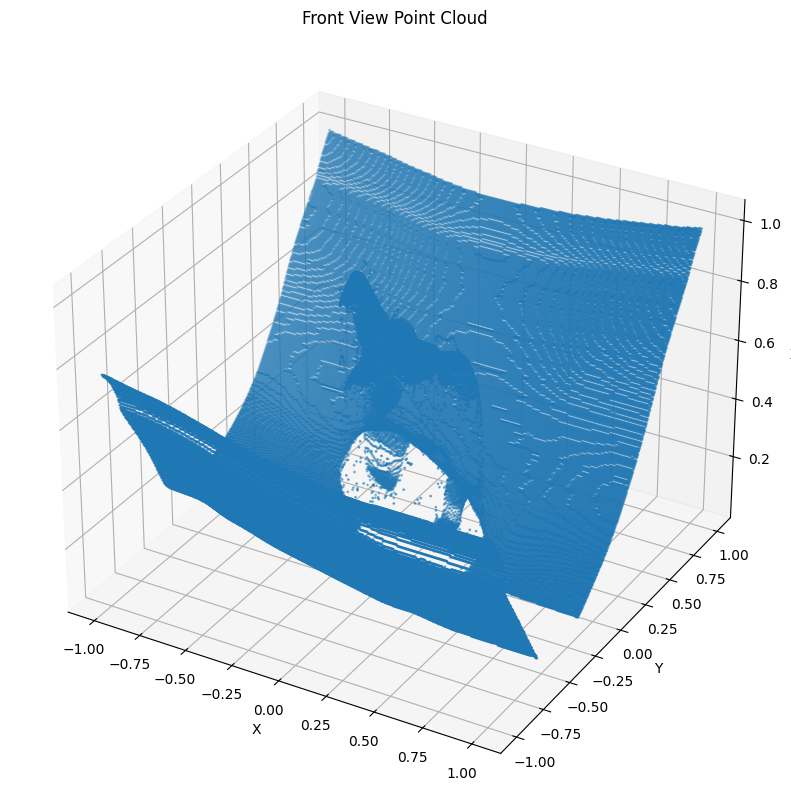


Plotting point cloud: Back View Point Cloud
Input points shape: (131644, 3)
Coordinate ranges:
X: [-1.000, 1.000]
Y: [-1.000, 1.000]
Z: [-1.000, -0.051]


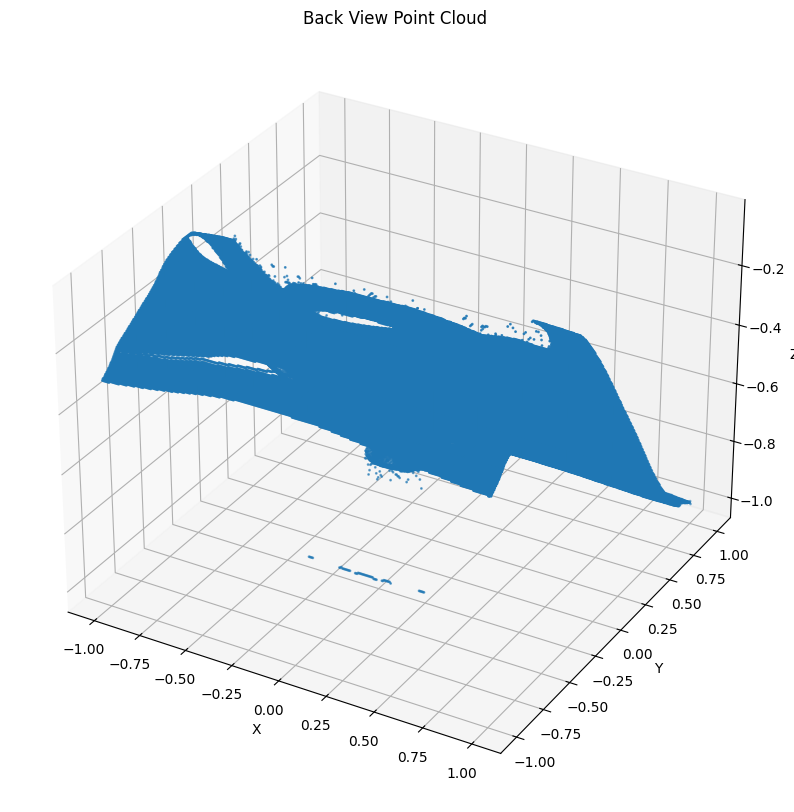


Plotting point cloud: Top View Point Cloud
Input points shape: (147141, 3)
Coordinate ranges:
X: [-1.000, 1.000]
Y: [0.051, 1.000]
Z: [-1.000, 1.000]


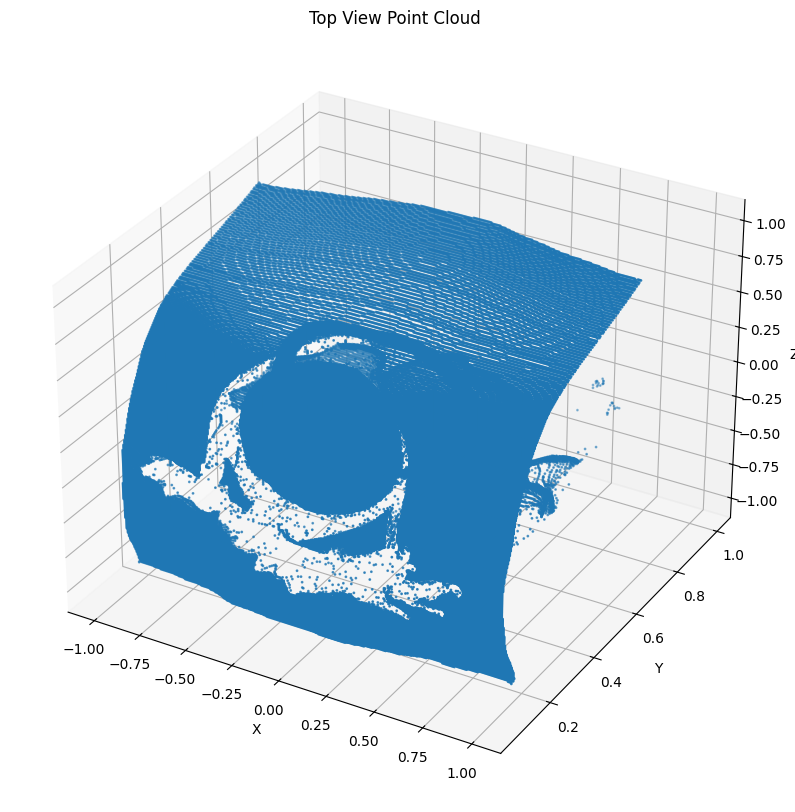


Combining point clouds with detailed analysis...

Starting point cloud combination process...

Point Cloud Analysis:

Front View Statistics:
Number of points: 136270
Coordinate ranges:
X: [-1.000, 1.000]
Y: [-1.000, 1.000]
Z: [0.054, 1.000]

Back View Statistics:
Number of points: 131644
Coordinate ranges:
X: [-1.000, 1.000]
Y: [-1.000, 1.000]
Z: [-1.000, -0.051]

Top View Statistics:
Number of points: 147141
Coordinate ranges:
X: [-1.000, 1.000]
Y: [0.051, 1.000]
Z: [-1.000, 1.000]

Performing point matching...
Processing point 0/136270
Processing point 1000/136270
Processing point 2000/136270
Processing point 3000/136270
Processing point 4000/136270
Processing point 5000/136270
Processing point 6000/136270
Processing point 7000/136270
Processing point 8000/136270
Processing point 9000/136270
Processing point 10000/136270
Processing point 11000/136270
Processing point 12000/136270
Processing point 13000/136270
Processing point 14000/136270
Processing point 15000/136270
Processing poi

ValueError: Expected 2D array of points, got shape (278, 1, 3)

In [20]:
# Previous imports and functions remain the same until combine_point_clouds

def analyze_point_distributions(front_points, back_points, top_points):
    """
    Analyze the distribution of points in each view to help with debugging
    """
    print("\nPoint Cloud Analysis:")
    for name, points in [("Front", front_points), ("Back", back_points), ("Top", top_points)]:
        print(f"\n{name} View Statistics:")
        print(f"Number of points: {len(points)}")
        print(f"Coordinate ranges:")
        print(f"X: [{points[:, 0].min():.3f}, {points[:, 0].max():.3f}]")
        print(f"Y: [{points[:, 1].min():.3f}, {points[:, 1].max():.3f}]")
        print(f"Z: [{points[:, 2].min():.3f}, {points[:, 2].max():.3f}]")

def combine_point_clouds(front_points, back_points, top_points, distance_threshold=0.2):
    """
    Combine point clouds with more lenient geometric consistency checking.
    Now includes detailed analysis of the matching process.
    """
    print("\nStarting point cloud combination process...")
    
    # First, analyze point distributions
    analyze_point_distributions(front_points, back_points, top_points)
    
    # Create KD-trees for efficient nearest neighbor search
    front_tree = KDTree(front_points)
    back_tree = KDTree(back_points)
    top_tree = KDTree(top_points)
    
    consistent_points = []
    consistency_scores = []
    
    # Track matching statistics
    total_points = len(front_points)
    matched_points = 0
    
    print("\nPerforming point matching...")
    for i, point in enumerate(front_points):
        if i % 1000 == 0:  # Progress update
            print(f"Processing point {i}/{total_points}")
            
        point_reshaped = point.reshape(1, -1)
        
        # Find nearest neighbors in other views
        back_dist, back_idx = back_tree.query(point_reshaped, k=1)
        top_dist, top_idx = top_tree.query(point_reshaped, k=1)
        
        back_point = back_points[back_idx[0]]
        top_point = top_points[top_idx[0]]
        
        # Calculate consistency scores
        front_back_dist = back_dist[0][0]
        front_top_dist = top_dist[0][0]
        
        # Use a weighted average based on confidence
        if front_back_dist < distance_threshold and front_top_dist < distance_threshold:
            # Weight points based on their distances
            total_dist = front_back_dist + front_top_dist + 1e-6  # Avoid division by zero
            weights = [
                1 / (front_back_dist + 1e-6),
                1 / (front_top_dist + 1e-6),
                1.0  # Weight for original point
            ]
            weights = np.array(weights) / sum(weights)
            
            # Compute weighted average point
            avg_point = (
                weights[0] * back_point +
                weights[1] * top_point +
                weights[2] * point
            )
            
            consistent_points.append(avg_point)
            consistency_scores.append(1 / (1 + front_back_dist + front_top_dist))
            matched_points += 1
    
    if len(consistent_points) == 0:
        print("Warning: No consistent points found! Try adjusting the distance_threshold.")
        return np.zeros((0, 3))
    
    consistent_points = np.array(consistent_points)
    consistency_scores = np.array(consistency_scores)
    
    print(f"\nMatching Statistics:")
    print(f"Total points processed: {total_points}")
    print(f"Points matched: {matched_points}")
    print(f"Match rate: {(matched_points/total_points)*100:.2f}%")
    print(f"Average consistency score: {np.mean(consistency_scores):.3f}")
    
    return consistent_points

# Use the same point cloud generation as before
print("Generating point clouds...")
front_points = generate_point_cloud(front_depth, 'front', threshold=0.05)  # Lower threshold
back_points = generate_point_cloud(back_depth, 'back', threshold=0.05)
top_points = generate_point_cloud(top_depth, 'top', threshold=0.05)

# Plot individual point clouds first
print("\nPlotting individual point clouds...")
for points, name in [(front_points, 'Front'), (back_points, 'Back'), (top_points, 'Top')]:
    try:
        plot_point_cloud(points, f'{name} View Point Cloud')
    except Exception as e:
        print(f"Error plotting {name} view: {str(e)}")
        print(f"Points shape: {points.shape}")
        print(f"First few points:\n{points[:5]}")
        
# Now combine with more detailed analysis
print("\nCombining point clouds with detailed analysis...")
combined_points = combine_point_clouds(
    front_points, 
    back_points, 
    top_points, 
    distance_threshold=0.2  # More lenient threshold
)

if len(combined_points) > 0:
    print("\nCreating final visualizations...")
    # Create standard plot
    plot_point_cloud(combined_points, 'Combined Point Cloud')
    
    # Create interactive Plotly visualization
    fig = go.Figure(data=[go.Scatter3d(
        x=combined_points[:, 0],
        y=combined_points[:, 1],
        z=combined_points[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=combined_points[:, 2],  # Color by Z coordinate
            colorscale='Viridis',
            opacity=0.8
        )
    )])

    fig.update_layout(
        title='Combined 3D Point Cloud',
        scene=dict(
            aspectmode='data',
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        margin=dict(l=0, r=0, b=0, t=0)
    )

    fig.show()
else:
    print("Still no points available. Let's analyze why:")
    # Additional debugging information
    print("\nPoint cloud properties:")
    for name, points in [("Front", front_points), ("Back", back_points), ("Top", top_points)]:
        print(f"\n{name} view:")
        print(f"Shape: {points.shape}")
        print(f"Non-zero points: {np.count_nonzero(np.abs(points).sum(axis=1))}")
        print(f"Value ranges: {points.min(axis=0)} to {points.max(axis=0)}")


Starting point cloud combination process...

Point Cloud Analysis:

Front View Statistics:
Number of points: 136270
Coordinate ranges:
X: [-1.000, 1.000]
Y: [-1.000, 1.000]
Z: [0.054, 1.000]

Back View Statistics:
Number of points: 131644
Coordinate ranges:
X: [-1.000, 1.000]
Y: [-1.000, 1.000]
Z: [-1.000, -0.051]

Top View Statistics:
Number of points: 147141
Coordinate ranges:
X: [-1.000, 1.000]
Y: [0.051, 1.000]
Z: [-1.000, 1.000]

Performing point matching...
Processing point 0/136270
Processing point 1000/136270
Processing point 2000/136270
Processing point 3000/136270
Processing point 4000/136270
Processing point 5000/136270
Processing point 6000/136270
Processing point 7000/136270
Processing point 8000/136270
Processing point 9000/136270
Processing point 10000/136270
Processing point 11000/136270
Processing point 12000/136270
Processing point 13000/136270
Processing point 14000/136270
Processing point 15000/136270
Processing point 16000/136270
Processing point 17000/136270
Proc

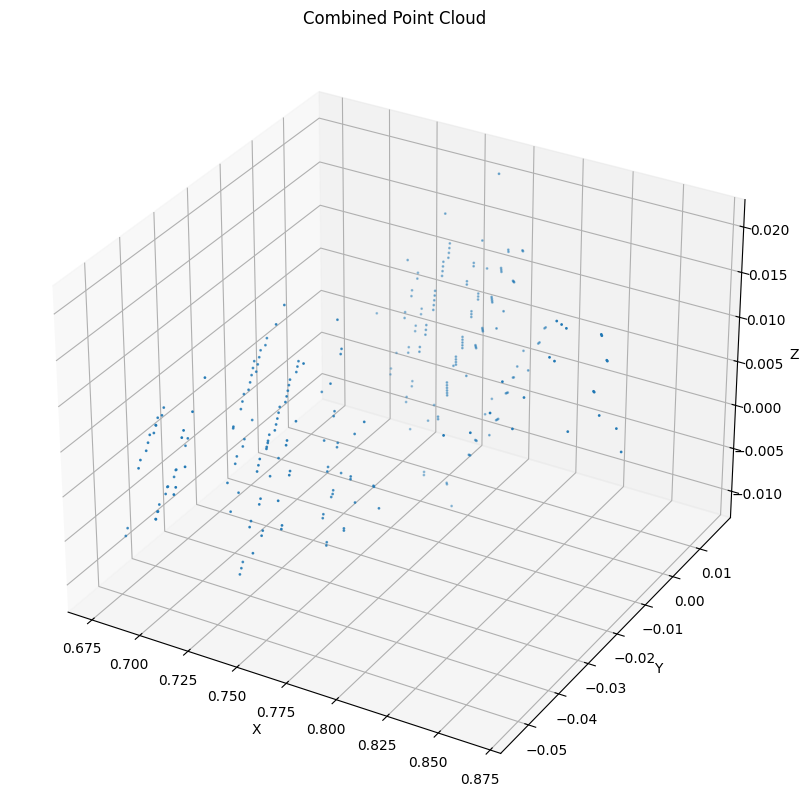

In [21]:
def combine_point_clouds(front_points, back_points, top_points, distance_threshold=0.2):
    """
    Combine point clouds with geometric consistency checking.
    
    We're working with three coordinate systems:
    - Front view: XY plane with Z depth
    - Back view: XY plane with negative Z depth
    - Top view: XZ plane with Y depth
    
    The function ensures points are consistent across all three views.
    """
    print("\nStarting point cloud combination process...")
    
    # First, analyze input point distributions
    analyze_point_distributions(front_points, back_points, top_points)
    
    # Create KD-trees for efficient neighbor search
    front_tree = KDTree(front_points)
    back_tree = KDTree(back_points)
    top_tree = KDTree(top_points)
    
    consistent_points = []
    consistency_scores = []
    
    total_points = len(front_points)
    matched_points = 0
    
    print("\nPerforming point matching...")
    for i, point in enumerate(front_points):
        if i % 1000 == 0:
            print(f"Processing point {i}/{total_points}")
            
        # Reshape point for KD-tree query without adding extra dimensions
        point_query = point.reshape(1, -1)
        
        # Find nearest neighbors
        back_dist, back_idx = back_tree.query(point_query, k=1)
        top_dist, top_idx = top_tree.query(point_query, k=1)
        
        # Get corresponding points
        back_point = back_points[back_idx[0]]
        top_point = top_points[top_idx[0]]
        
        # Calculate consistency
        front_back_dist = np.linalg.norm(point - back_point)
        front_top_dist = np.linalg.norm(point - top_point)
        
        if front_back_dist < distance_threshold and front_top_dist < distance_threshold:
            # Calculate weights based on distances
            total_dist = front_back_dist + front_top_dist + 1e-6
            weights = np.array([
                1 / (front_back_dist + 1e-6),
                1 / (front_top_dist + 1e-6),
                1.0
            ])
            weights = weights / np.sum(weights)
            
            # Compute weighted average point - ensure we're keeping 3D coordinates
            avg_point = np.array([
                weights[0] * back_point +
                weights[1] * top_point +
                weights[2] * point
            ])
            
            # Store the point without extra dimensions
            consistent_points.append(avg_point.flatten())
            consistency_scores.append(1 / (1 + total_dist))
            matched_points += 1
    
    if len(consistent_points) == 0:
        print("Warning: No consistent points found! Try adjusting the distance_threshold.")
        return np.zeros((0, 3))
    
    # Convert to numpy array and ensure correct shape (N, 3)
    consistent_points = np.array(consistent_points)
    if len(consistent_points.shape) > 2:
        consistent_points = consistent_points.reshape(-1, 3)
    
    consistency_scores = np.array(consistency_scores)
    
    print(f"\nMatching Statistics:")
    print(f"Total points processed: {total_points}")
    print(f"Points matched: {matched_points}")
    print(f"Match rate: {(matched_points/total_points)*100:.2f}%")
    print(f"Average consistency score: {np.mean(consistency_scores):.3f}")
    print(f"Final point cloud shape: {consistent_points.shape}")
    
    # Validate the final shape
    assert len(consistent_points.shape) == 2 and consistent_points.shape[1] == 3, \
        f"Invalid point cloud shape: {consistent_points.shape}"
    
    return consistent_points

def validate_point_cloud(points, name=""):
    """
    Validate a point cloud's shape and content.
    This helps us catch issues early in the process.
    """
    if not isinstance(points, np.ndarray):
        raise TypeError(f"{name} points must be a numpy array")
        
    if len(points.shape) != 2:
        points = points.reshape(-1, 3)
        print(f"Reshaped {name} points from {points.shape} to (-1, 3)")
        
    if points.shape[1] != 3:
        raise ValueError(f"{name} points must have 3 coordinates per point")
        
    return points

# When processing point clouds, add validation:
combined_points = combine_point_clouds(front_points, back_points, top_points)
combined_points = validate_point_cloud(combined_points, "combined")

# Now plot with validated points
plot_point_cloud(combined_points, 'Combined Point Cloud')